In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/mymoviedb.csv", lineterminator="\n")

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [5]:
df.dtypes

,0
Release_Date,object
Title,object
Overview,object
Popularity,float64
Vote_Count,int64
Vote_Average,float64
Original_Language,object
Genre,object
Poster_Url,object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


• looks like our dataset has no NaNs! • Overview, Original_Language and Poster-Url
wouldn't be so useful during analysis • Release_Date column needs to be casted into
date time and to extract only the year value

In [7]:
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


• genres are saperated by commas followed by whitespaces.

In [8]:
df.duplicated().sum()

np.int64(0)

• our dataset has no duplicated rows either.

• Exploration Summary

• we have a dataframe consisting of 9827 rows and 9 columns.

• our dataset looks a bit tidy with no NaNs nor duplicated values.

• Release_Date column needs to be casted into date time and to extract only the year value.

• Overview, Original_Languege and Poster-Url wouldn't be so useful during analys, so we will drop them.

• there is noticable outliers in Popularity column.

• Vote_Average bettter be categorised for proper analysis.

• Genre column has comma saperated values and white spaces that needs to be handled and casted into category.Exploration summary.

In [9]:
#data cleaning

Casting Release_Date column and extracing year values

In [10]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)

datetime64[ns]


In [11]:
df['Release_Year'] = df['Release_Date'].dt.year
df['Release_Year'].dtypes

dtype('int32')

In [12]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Release_Year
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,2021
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,2022
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,2022
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,2021
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,2021


Dropping the unnecessary columns

In [13]:
cols=['Overview','Original_Language','Poster_Url']
df.drop(cols, axis=1, inplace=True)

In [14]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre', 'Release_Year'],
      dtype='object')

In [15]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction",2021
1,2022-03-01,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller",2022
2,2022-02-25,No Exit,2618.087,122,6.3,Thriller,2022
3,2021-11-24,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy",2021
4,2021-12-22,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War",2021


**categorizing Vote_Average column**

We would cut the Vote_Average values and make 4 categories: popular, average,
below_avg, not_popular to describe it more using catigorize_col() function
provided above.

In [16]:
def categorize_col(df,col,labels):
  edges=[
      df[col].describe()['min'],
      df[col].describe()['25%'],
      df[col].describe()['50%'],
      df[col].describe()['75%'],
      df[col].describe()['max']
  ]
  df[col] = pd.cut(df[col],edges,labels=labels, duplicates = 'drop')
  return df

In [17]:
 labels=['Not_Popular','Below_Avg','Average','Popular',]
 categorize_col(df,'Vote_Average',labels)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction",2021
1,2022-03-01,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller",2022
2,2022-02-25,No Exit,2618.087,122,Below_Avg,Thriller,2022
3,2021-11-24,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy",2021
4,2021-12-22,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War",2021
...,...,...,...,...,...,...,...
9822,1973-10-15,Badlands,13.357,896,Popular,"Drama, Crime",1973
9823,2020-10-01,Violent Delights,13.356,8,Not_Popular,Horror,2020
9824,2016-05-06,The Offering,13.355,94,Not_Popular,"Mystery, Thriller, Horror",2016
9825,2021-03-31,The United States vs. Billie Holiday,13.354,152,Average,"Music, Drama, History",2021


In [18]:
df['Vote_Average'].unique()

['Popular', 'Below_Avg', 'Average', 'Not_Popular', NaN]
Categories (4, object): ['Not_Popular' < 'Below_Avg' < 'Average' < 'Popular']

In [19]:
df['Vote_Average'].value_counts()

,count
Vote_Average,
Not_Popular,2467
Popular,2450
Average,2412
Below_Avg,2398


In [21]:
df.dropna(inplace=True)

In [22]:
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0
Release_Year,0


**we'd split genres into a list and then
explode our dataframe to have only one
genre per row for ezch movie**

In [23]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction",2021
1,2022-03-01,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller",2022
2,2022-02-25,No Exit,2618.087,122,Below_Avg,Thriller,2022
3,2021-11-24,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy",2021
4,2021-12-22,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War",2021


In [25]:
df['Genre']= df['Genre'].str.split(', ')
df=df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction,2021
3,2022-03-01,The Batman,3827.658,1151,Popular,Crime,2022
4,2022-03-01,The Batman,3827.658,1151,Popular,Mystery,2022


Casting column into category

In [26]:
df['Genre'] = df['Genre'].astype('category')

In [31]:
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Release_Date  25552 non-null  datetime64[ns]
 1   Title         25552 non-null  object        
 2   Popularity    25552 non-null  float64       
 3   Vote_Count    25552 non-null  int64         
 4   Vote_Average  25552 non-null  category      
 5   Genre         25552 non-null  category      
 6   Release_Year  25552 non-null  int32         
dtypes: category(2), datetime64[ns](1), float64(1), int32(1), int64(1), object(1)
memory usage: 949.2+ KB


In [33]:
df.nunique()

,0
Release_Date,5846
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19
Release_Year,100


# **Data Visualization**

In [34]:
sns.set_style('whitegrid')

Q1: What is the most frequent genre in
the dataset?

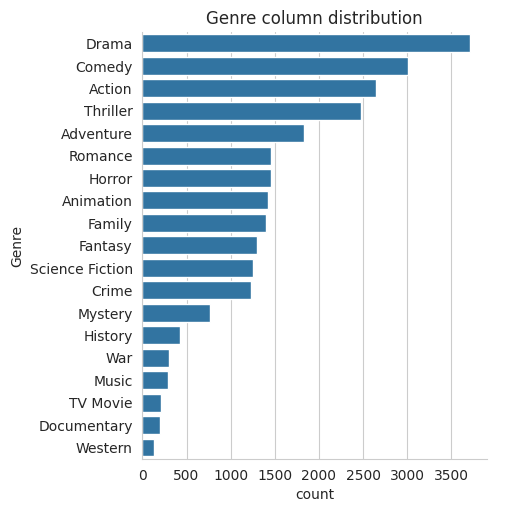

In [37]:
sns.catplot(y='Genre', data=df,kind='count', order=df['Genre'].value_counts().index)
plt.title("Genre column distribution")
plt.show()

Q2: What genres has highest votes ?

In [38]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction,2021
3,2022-03-01,The Batman,3827.658,1151,Popular,Crime,2022
4,2022-03-01,The Batman,3827.658,1151,Popular,Mystery,2022


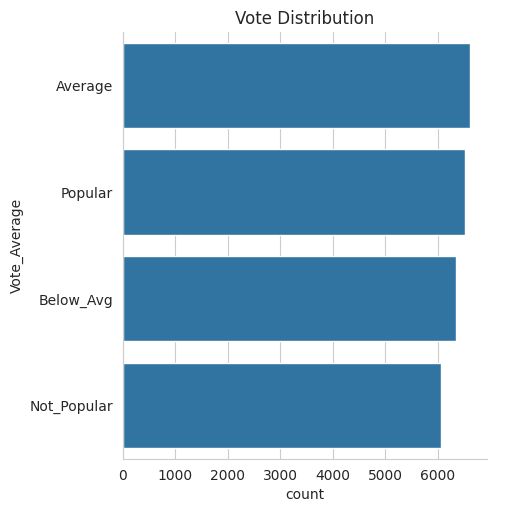

In [57]:
sns.catplot(y='Vote_Average', data =df, kind='count',order=df['Vote_Average'].value_counts().index)
plt.title("Vote Distribution")
plt.show()


Q3: What movie got the highest popularity ? what's its
genre ?

In [60]:
df[df['Popularity']== df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction,2021


Q4: What movie got the lowest popularity? what's
its genre?

In [61]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
25546,2021-03-31,The United States vs. Billie Holiday,13.354,152,Average,Music,2021
25547,2021-03-31,The United States vs. Billie Holiday,13.354,152,Average,Drama,2021
25548,2021-03-31,The United States vs. Billie Holiday,13.354,152,Average,History,2021
25549,1984-09-23,Threads,13.354,186,Popular,War,1984
25550,1984-09-23,Threads,13.354,186,Popular,Drama,1984
25551,1984-09-23,Threads,13.354,186,Popular,Science Fiction,1984


Q5: Which year has the most filmmed movies?

In [62]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Release_Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction,2021
3,2022-03-01,The Batman,3827.658,1151,Popular,Crime,2022
4,2022-03-01,The Batman,3827.658,1151,Popular,Mystery,2022


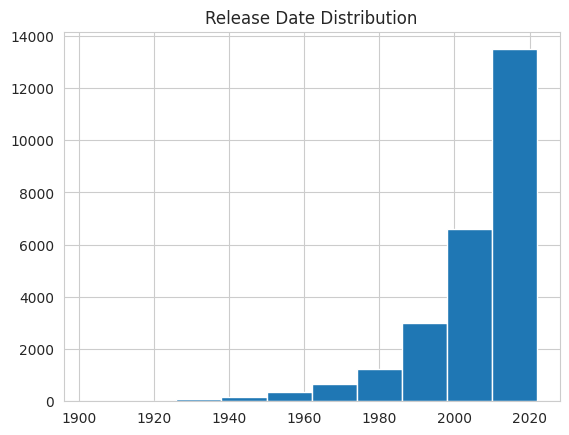

In [63]:
df['Release_Year'].hist()
plt.title("Release Date Distribution")
plt.show()

Q1: What is the most frequent genre in the dataset?

* Drama genre is the most frequent genre in our dataset and has appeared
more than
14% of the times among 19 other genres.


Q2: What genres has highest votes ?

* we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the
highest popularity among fans by being having more than 18.5% of movies popularities.

Q3: What movie got the highest popularity ? what's its genre ?

* Spider-Man: No Way Home has the highest popularity rate in our dataset and it has
genres of Action , Adventure and Sience Fiction .

Q4: What movie got the lowest popularity ? what's its genre ?

* The united states, thread' has the highest lowest rate in our dataset
and it has genres of music , drama , 'war', 'sci-fi' and history`.

Q5: Which year has the most filmmed movies?

* year 2020 has the highest filmming rate in our dataset.